## Model Performance Metrics

In [7]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from pathlib import Path

# Add project root to path
project_root = Path(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(project_root)

from src.utils.model_loader import load_model
from src.pipeline.datasets import ProductDataset
from torch.utils.data import DataLoader


### Load Model, Data, and Labels

In [8]:
# Load model and label mapping using absolute paths
model_path = str(project_root / "models/best_model.pth")
label_mapping_path = str(project_root / "src/data/label_mapping.json")
model, label_mapping = load_model(model_path, label_mapping_path)
model.eval()

# Load test/validation data using absolute path
df = pd.read_csv(str(project_root / "src/data/final_cnn_training_data.csv"))
image_paths = df['image_path'].tolist()
labels = df['label'].astype(int).tolist()

# Prepare dataset and dataloader with project_root for path resolution
dataset = ProductDataset(image_paths, labels, project_root=project_root)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

[DEBUG] Current working directory: c:\Users\don\dev\ds_test\notebooks
[DEBUG] Model path (as passed): c:\Users\don\dev\ds_test\models\best_model.pth
[DEBUG] Model path (absolute): c:\Users\don\dev\ds_test\models\best_model.pth


### Get Predictions and True Labels

In [9]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

### Accuracy and F1 Score

In [10]:
acc = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_micro = f1_score(all_labels, all_preds, average='micro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Accuracy: 0.2037
F1 Macro: 0.1829
F1 Micro: 0.2037
F1 Weighted: 0.2049


### Confusion Matrix Visualization

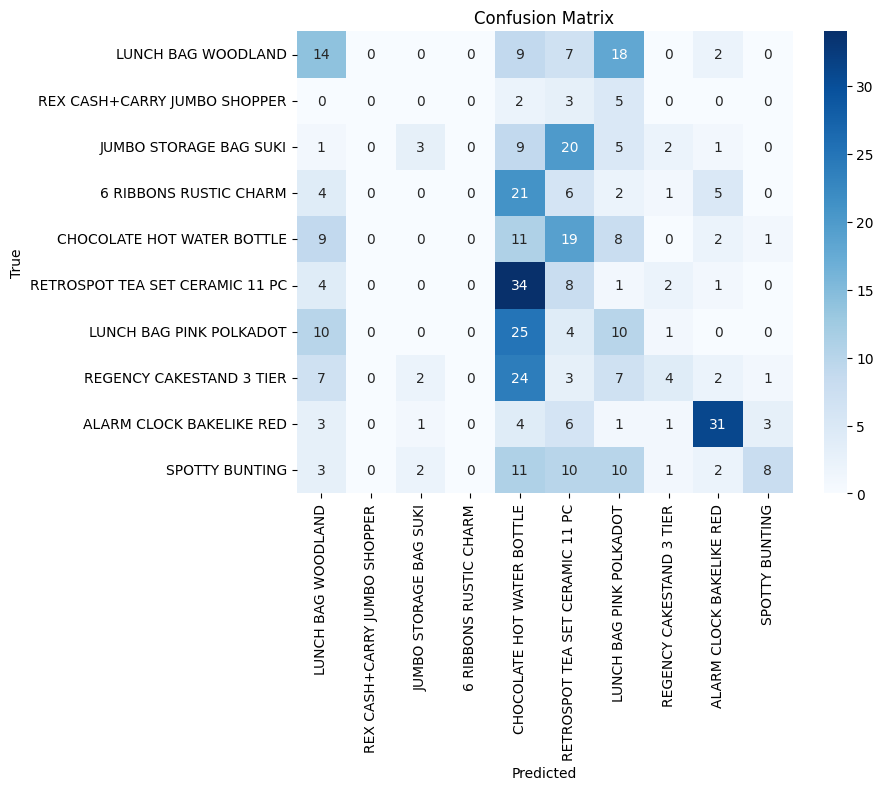

In [11]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_mapping[str(i)] for i in range(len(label_mapping))],
            yticklabels=[label_mapping[str(i)] for i in range(len(label_mapping))])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [12]:
print(classification_report(all_labels, all_preds, target_names=[label_mapping[str(i)] for i in range(len(label_mapping))]))

                                 precision    recall  f1-score   support

             LUNCH BAG WOODLAND       0.25      0.28      0.27        50
   REX CASH+CARRY JUMBO SHOPPER       0.00      0.00      0.00        10
         JUMBO STORAGE BAG SUKI       0.38      0.07      0.12        41
         6 RIBBONS RUSTIC CHARM       0.00      0.00      0.00        39
     CHOCOLATE HOT WATER BOTTLE       0.07      0.22      0.11        50
RETROSPOT TEA SET CERAMIC 11 PC       0.09      0.16      0.12        50
        LUNCH BAG PINK POLKADOT       0.15      0.20      0.17        50
       REGENCY CAKESTAND 3 TIER       0.33      0.08      0.13        50
       ALARM CLOCK BAKELIKE RED       0.67      0.62      0.65        50
                 SPOTTY BUNTING       0.62      0.17      0.27        47

                       accuracy                           0.20       437
                      macro avg       0.26      0.18      0.18       437
                   weighted avg       0.28      0

c:\Users\don\dev\ds_test\venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\don\dev\ds_test\venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\don\dev\ds_test\venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### ROC Curve for Each Class

In [13]:
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC AUC (One-vs-Rest)
n_classes = len(label_mapping)
y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))
y_pred_bin = label_binarize(all_preds, classes=list(range(n_classes)))

# Compute ROC AUC for each class
for i in range(n_classes):
    try:
        auc = roc_auc_score(y_true_bin[:, i], y_pred_bin[:, i])
        print(f"Class {i} ({label_mapping[str(i)]}): ROC AUC = {auc:.4f}")
    except ValueError:
        print(f"Class {i} ({label_mapping[str(i)]}): ROC AUC not defined (only one class present)")

Class 0 (LUNCH BAG WOODLAND): ROC AUC = 0.5870
Class 1 (REX CASH+CARRY JUMBO SHOPPER): ROC AUC = 0.5000
Class 2 (JUMBO STORAGE BAG SUKI): ROC AUC = 0.5303
Class 3 (6 RIBBONS RUSTIC CHARM): ROC AUC = 0.5000
Class 4 (CHOCOLATE HOT WATER BOTTLE): ROC AUC = 0.4304
Class 5 (RETROSPOT TEA SET CERAMIC 11 PC): ROC AUC = 0.4792
Class 6 (LUNCH BAG PINK POLKADOT): ROC AUC = 0.5264
Class 7 (REGENCY CAKESTAND 3 TIER): ROC AUC = 0.5297
Class 8 (ALARM CLOCK BAKELIKE RED): ROC AUC = 0.7906
Class 9 (SPOTTY BUNTING): ROC AUC = 0.5787
